# Выбор локации для скважины

Мы работаете в добывающей компании «ГлавРосГосНефть». Нужно решить, где бурить новую скважину. 
Шаги для выбора локации такие:
В избранном регионе собирают характеристики для скважин: качество нефти и объём её запасов;
Строят модель для предсказания объёма запасов в новых скважинах;
Выбирают скважины с самыми высокими оценками значений;
Определяют регион с максимальной суммарной прибылью отобранных скважин.
Нам предоставлены пробы нефти в трёх регионах. Характеристики для каждой скважины в регионе уже известны.Нужно построить модель для определения региона, где добыча принесёт наибольшую прибыль. Проанализировать возможную прибыль и риски техникой Bootstrap.

## Загрузка данных

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

In [2]:
try:
    first_geo = pd.read_csv('/datasets/geo_data_0.csv', decimal=',')
    second_geo = pd.read_csv('/datasets/geo_data_1.csv', decimal=',')
    third_geo = pd.read_csv('/datasets/geo_data_2.csv', decimal=',')
except: 
    first_geo = pd.read_csv('C:\\Users\\andre\\Downloads\\geo_data_0.csv', decimal=',')
    second_geo = pd.read_csv('C:\\Users\\andre\\Downloads\\geo_data_1.csv', decimal=',')
    third_geo = pd.read_csv('C:\\Users\\andre\\Downloads\\geo_data_2.csv', decimal=',')

In [3]:
regions = [first_geo,second_geo,third_geo]
for region in regions:
    display(region.head())
    display(region.info())

,id,f0,f1,f2,product
0,txEyH,0.7057449842080644,-0.4978225001976334,1.22116994843607,105.28006184349583
1,2acmU,1.3347112926051892,-0.3401642528583136,4.3650803324282,73.03775026515737
2,409Wp,1.0227322634721168,0.15199044457022945,1.4199262386740652,85.26564713099945
3,iJLyR,-0.03217162450743976,0.13903270818447744,2.9785659663204838,168.62077555509563
4,Xdl7t,1.988431059439699,0.15541267777667178,4.751769119262962,154.03664673738086


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   id       100000 non-null  object
 1   f0       100000 non-null  object
 2   f1       100000 non-null  object
 3   f2       100000 non-null  object
 4   product  100000 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


None

,id,f0,f1,f2,product
0,kBEdx,-15.00134818249185,-8.275999947188001,-0.005876013693320655,3.179102583207246
1,62mP7,14.272087811011147,-3.47508321506002,0.9991827365665829,26.95326103153969
2,vyE1P,6.263187352448809,-5.948385788285711,5.001160160764809,134.76630515769844
3,KcrkZ,-13.081196289023516,-11.506056864519605,4.999414898074921,137.94540774090564
4,AHL4O,12.702194885533585,-8.147433374146587,5.00436255224226,134.76630515769844


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   id       100000 non-null  object
 1   f0       100000 non-null  object
 2   f1       100000 non-null  object
 3   f2       100000 non-null  object
 4   product  100000 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


None

,id,f0,f1,f2,product
0,fwXo0,-1.1469870984179529,0.9633279217162892,-0.8289649221710994,27.758673230730036
1,WJtFt,0.2627779016539684,0.2698389572803021,-2.530186515492004,56.06969663239464
2,ovLUW,0.19458728165865746,0.2890350017576741,-5.586432770903118,62.87191004763475
3,q6cA6,2.2360596126935817,-0.5537598999099264,0.930037615920042,114.57284166750858
4,WPMUX,-0.5159928644136754,1.7162655596688288,5.899011469346728,149.60074591275887


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   id       100000 non-null  object
 1   f0       100000 non-null  object
 2   f1       100000 non-null  object
 3   f2       100000 non-null  object
 4   product  100000 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


None

Датасеты содержат: 
id — уникальный идентификатор скважины;
f0, f1, f2 — три признака точек (неважно, что они означают, но сами признаки значимы);
product — объём запасов в скважине (тыс. баррелей).

## Предобработка данных


Проверка на дубликаты в ид.

In [4]:
for region in regions:
    display(region['id'].duplicated().sum())

10

4

4

In [5]:
for region in regions:
    region.drop_duplicates(subset=['id'], inplace=True)


In [6]:
for region in regions:
    display(region['id'].duplicated().sum())

0

0

0

In [7]:
for region in regions:
    display(region.duplicated().sum())

0

0

0

In [8]:
for region in regions:
    display(region.isna().sum())

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

Пропусков не обнаружено. дубликаты по индексам удалены.

## Исследовательский анализ данных

In [9]:
for region in regions:
    numeric_cols = ['f0', 'f1', 'f2', 'product']
    region[numeric_cols] = region[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [10]:
for region in regions:
    display(region.describe().T)

,count,mean,std,min,25%,50%,75%,max
f0,99990.0,0.500454,0.871844,-1.408605,-0.072572,0.502405,1.073626,2.362331
f1,99990.0,0.250141,0.504430,-0.848218,-0.200877,0.250252,0.700640,1.343769
f2,99990.0,2.502629,3.248149,-12.088328,0.287784,2.515969,4.715035,16.003790
product,99990.0,92.499684,44.288304,0.000000,56.497069,91.847928,128.563699,185.364347


,count,mean,std,min,25%,50%,75%,max
f0,99996.0,1.141209,8.965815,-31.609576,-6.298551,1.153055,8.620964,29.421755
f1,99996.0,-4.796608,5.119906,-26.358598,-8.267985,-4.813172,-1.332816,18.734063
f2,99996.0,2.494501,1.703579,-0.018144,1.000021,2.011475,3.999904,5.019721
product,99996.0,68.823916,45.944663,0.000000,26.953261,57.085625,107.813044,137.945408


,count,mean,std,min,25%,50%,75%,max
f0,99996.0,0.002002,1.732052,-8.760004,-1.162328,0.009424,1.158477,7.238262
f1,99996.0,-0.002159,1.730397,-7.084020,-1.174841,-0.009661,1.163523,7.844801
f2,99996.0,2.495084,3.473482,-11.970335,0.130269,2.484236,4.858720,16.739402
product,99996.0,94.998342,44.749573,0.000000,59.450028,94.925026,130.586815,190.029838


'Регион 0:'

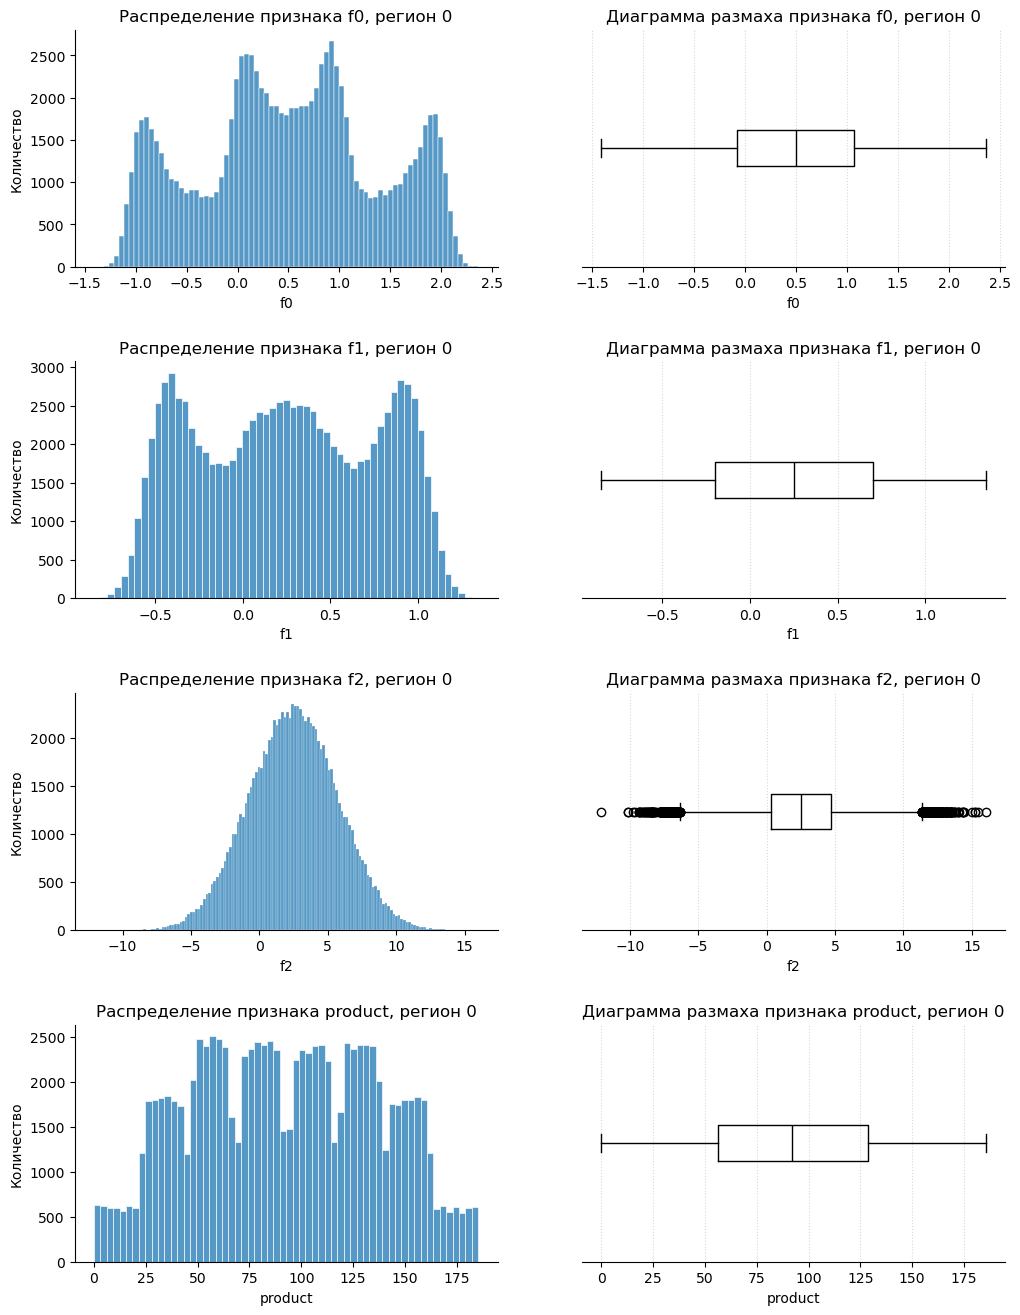

'Регион 1:'

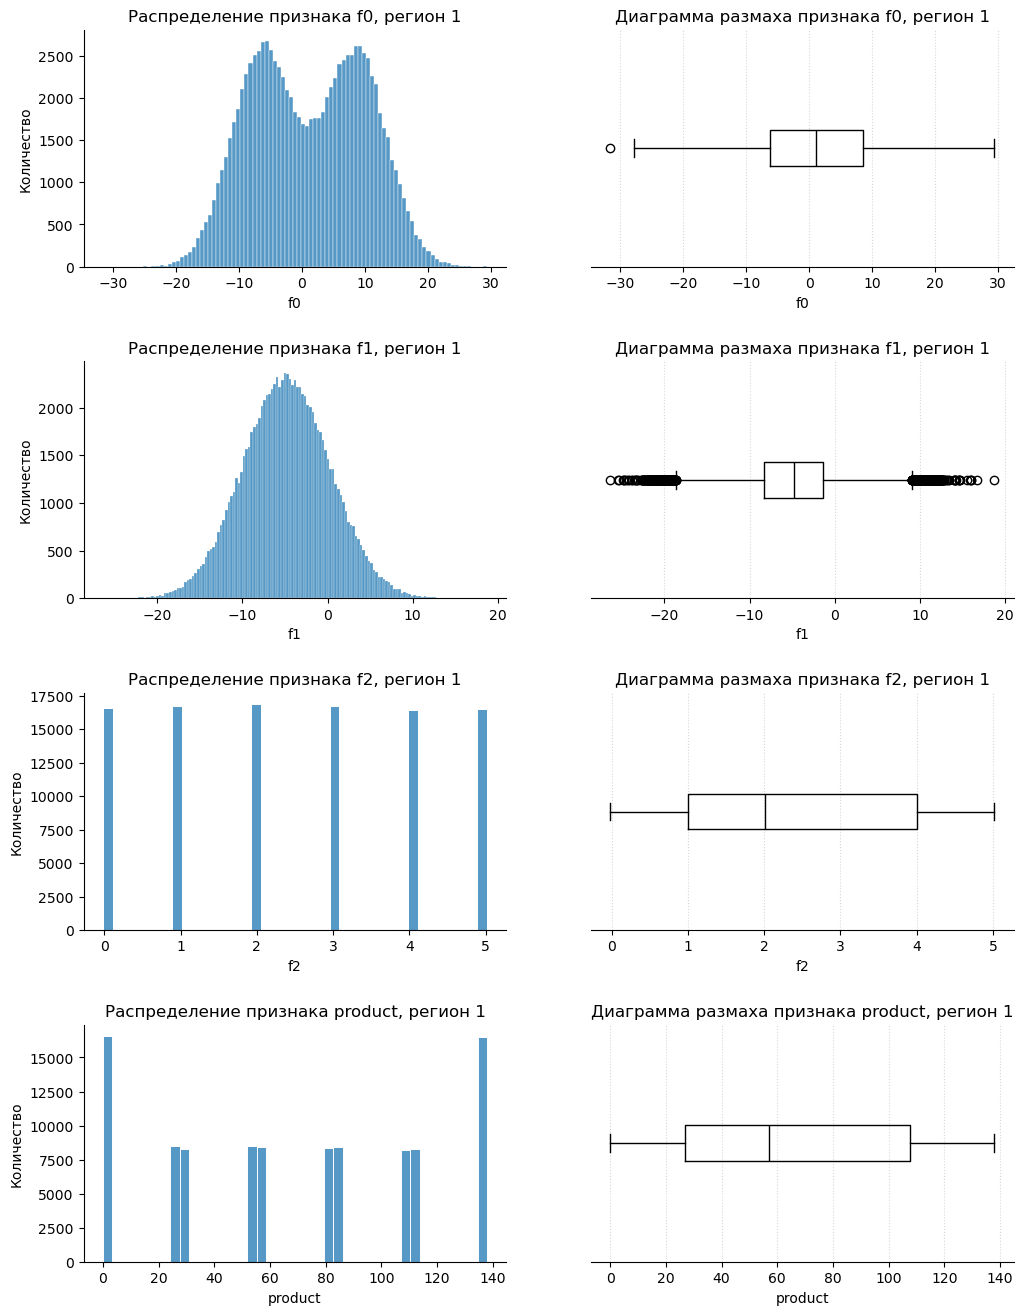

'Регион 2:'

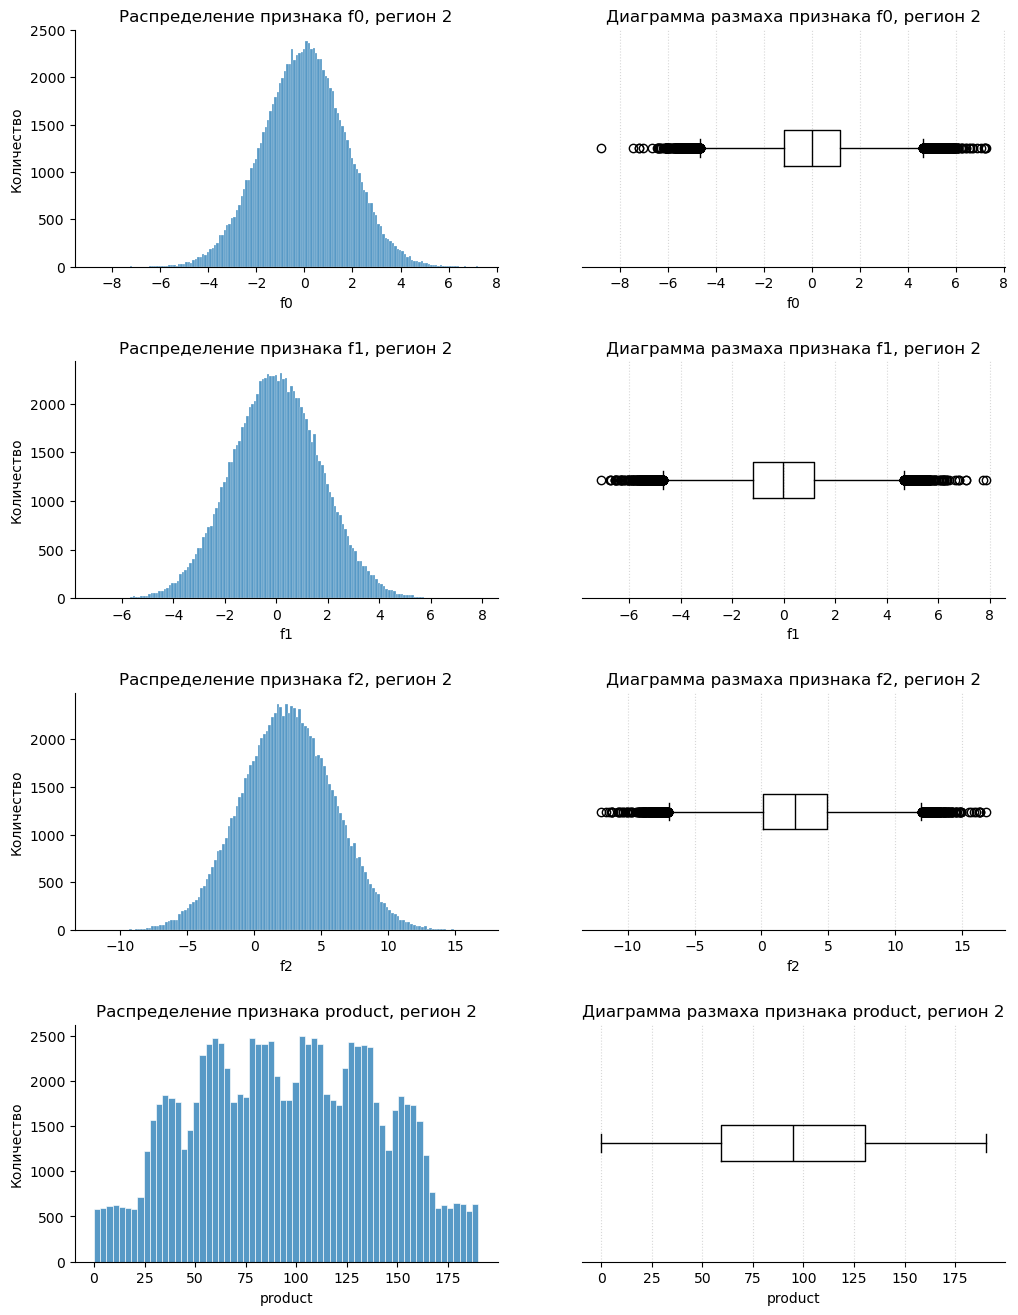

In [11]:
for key, region in enumerate(regions):
    num_col_names = region.select_dtypes(include='number').columns
    
    n = len(num_col_names)
    fig, axes = plt.subplots(n, 2, figsize=(12, n * 4))
    fig.subplots_adjust(hspace=0.4)
    
    for i, col_name in enumerate(num_col_names):
        ax1, ax2 = axes[i, 0], axes[i, 1]
    
        sns.histplot(data=region, x=col_name, ax=ax1, edgecolor='white')
        ax1.set_title(f'Распределение признака {col_name}, регион {key}')
        ax1.set_xlabel(col_name)
        ax1.set_ylabel('Количество')
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
    
        region[col_name].plot(kind='box', vert=False, ax=ax2, color='black')
        ax2.set_title(f'Диаграмма размаха признака {col_name}, регион {key}')
        ax2.set_xlabel(col_name)
        ax2.set_yticklabels([])
        ax2.set_yticks([])
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.spines['left'].set_visible(False)
        ax2.grid(axis='x', alpha=0.5, linestyle=':')

    display(f'Регион {key}:')
    plt.show()

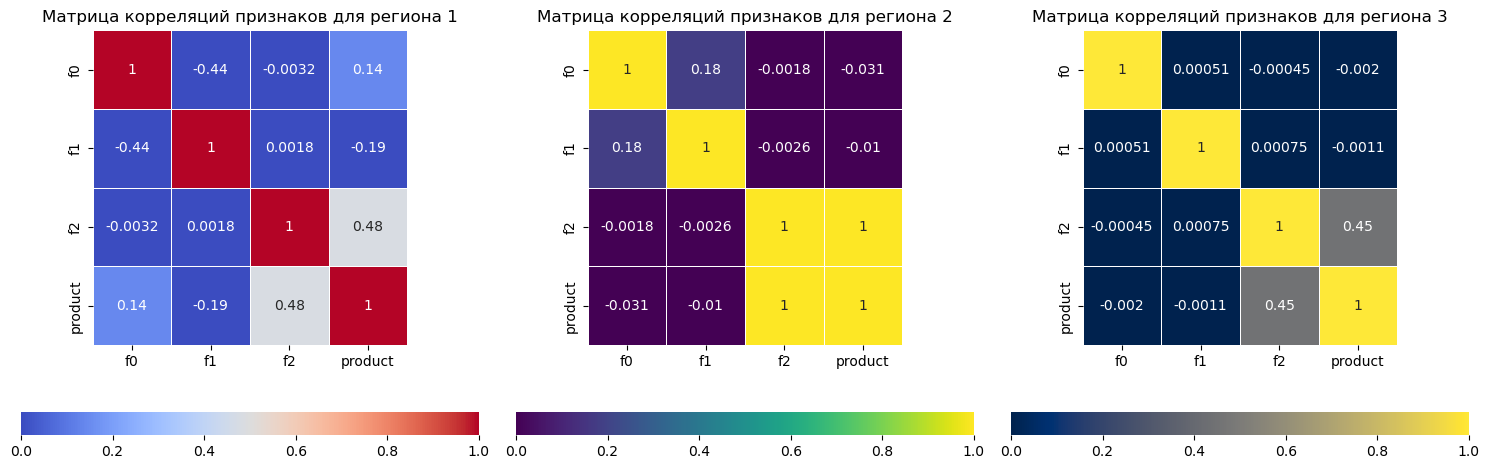

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

CMAPS = [sns.color_palette("coolwarm", as_cmap=True),
         sns.color_palette("viridis", as_cmap=True),
         sns.color_palette("cividis", as_cmap=True)]

n = len(regions)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))

if n == 1:
    axes = [axes]

for key, region in enumerate(regions):
    interval_col_names = region.select_dtypes(include='number').columns
    corr_coefficients = region.drop('id', axis=1).corr()
    
    sns.heatmap(corr_coefficients, vmin=0, vmax=1, cmap=CMAPS[key], annot=True, linewidths=0.5, 
                cbar=True, cbar_kws={'orientation': 'horizontal'}, square=True, ax=axes[key])
    axes[key].set_title(f'Матрица корреляций признаков для региона {key + 1}')

plt.tight_layout()
plt.show()


Признаки f0, f1 и f2 связаны с объемом запасов в скважинах, причем признак f2 демонстрирует наиболее стабильную и сильную корреляцию во всех регионах. В регионах 1 и 3 именно f2 является ключевым фактором для оценки запасов, а взаимодействие между признаками также может играть роль при моделировании запасов. 

Регион 0:


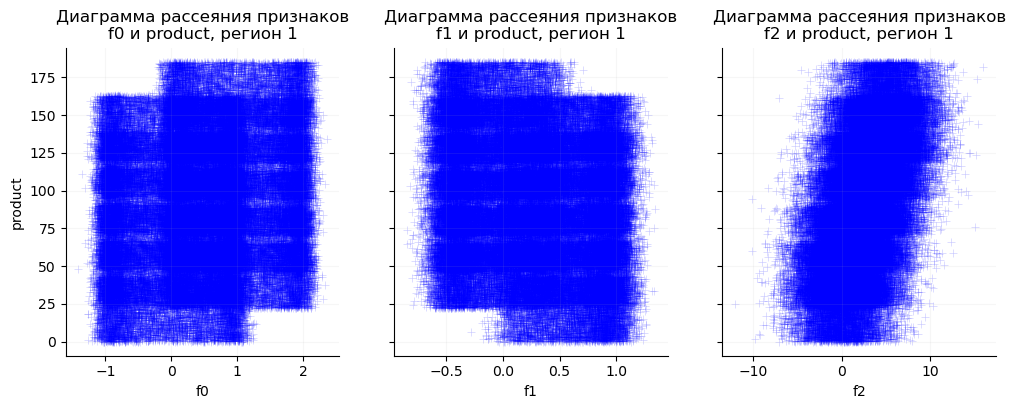

Регион 1:


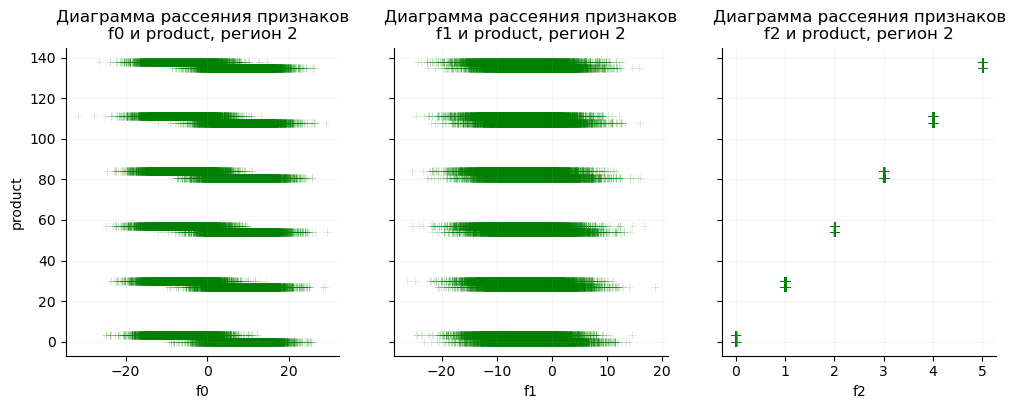

Регион 2:


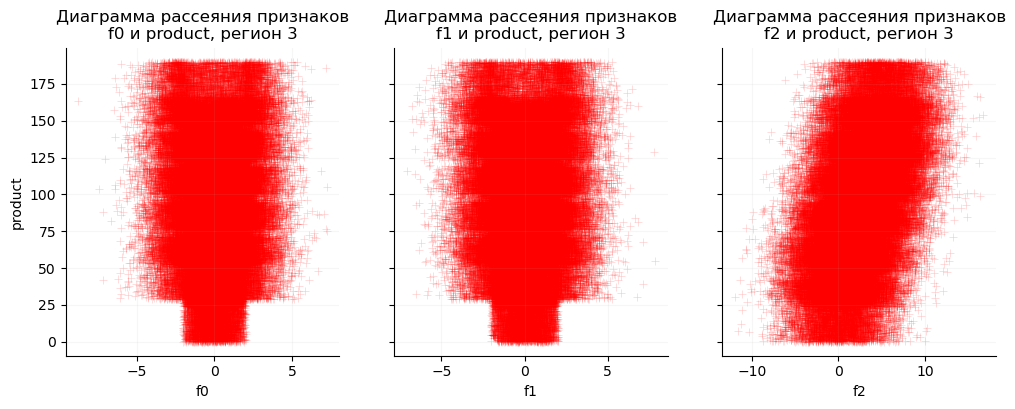

In [13]:
COLORS = ['blue', 'green', 'red']

target_col_name = 'product'

for key, region in enumerate(regions):
    num_col_names = region.select_dtypes(include='number').columns.drop(target_col_name)
    n = len(num_col_names)
    
    fig, axes = plt.subplots(1, n, figsize=(n * 4, 4), sharey=True)
    
    if n == 1:
        axes = [axes]
        
    for i, col_name in enumerate(num_col_names):
        ax = axes[i]
        
        sns.scatterplot(
            data=region, x=col_name, y=target_col_name,
            marker='+', ax=ax, alpha=0.2, color=COLORS[key]
        )
        ax.set_title(f'Диаграмма рассеяния признаков\n{col_name} и {target_col_name}, регион {key + 1}')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(alpha=0.1)
    
    print(f'Регион {key}:')
    plt.show()

Заметна линейная зависимость во 2 регионе признак f2 точно характеризует целевой признак

## Обучение и проверка модели


In [14]:
RANDOM_STATE = 42
pipe_preprocessor = ColumnTransformer(
    transformers=[('num', MinMaxScaler(), ['f0', 'f1', 'f2'])], 
    remainder='drop'
)

pipe_final = Pipeline(
    steps=[('preprocessor', pipe_preprocessor),
           ('model', LinearRegression(fit_intercept=True))]
)

In [15]:
splitted_regions = []
for key, region in enumerate(regions):
    train, valid = train_test_split(region.copy(), test_size=0.25, random_state=RANDOM_STATE)
    splitted_regions.append({'train': train, 'valid': valid})

In [16]:
for key, splitted_region in enumerate(splitted_regions):  
    X_train = splitted_region['train'].drop('product', axis=1)
    y_train = splitted_region['train']['product']
    X_test = splitted_region['valid'].drop('product', axis=1)
    y_test = splitted_region['valid']['product']

    model = clone(pipe_final)
    model.fit(X_train, y_train)

    splitted_regions[key]['valid']['product_pred'] = model.predict(X_test)

In [17]:
results = pd.DataFrame(columns=['Cредний объём запасов в скважине', 'RMSE модели'])
for key, splitted_region in enumerate(splitted_regions):
    product_mean = splitted_region['valid']['product_pred'].mean()
    rmse_score = mean_squared_error(splitted_region['valid']['product'], 
                              splitted_region['valid']['product_pred'], 
                              squared=False)
    results.loc[f'Регион {key}'] = [product_mean.round(2), rmse_score.round(2)]
results

C:\Users\andre\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\andre\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\andre\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,Cредний объём запасов в скважине,RMSE модели
Регион 0,92.61,37.69
Регион 1,68.58,0.89
Регион 2,94.93,40.08


Как и ожидалось, высокая связь признака f2
 с целевым признаком product
 в регионе 1 положительно повлияла на качество модели — корень среднеквадратичной ошибки (RMSE) для этой модели равен 0.89, что значительно ниже, чем у моделей для других регионов.

'Регион 0:'

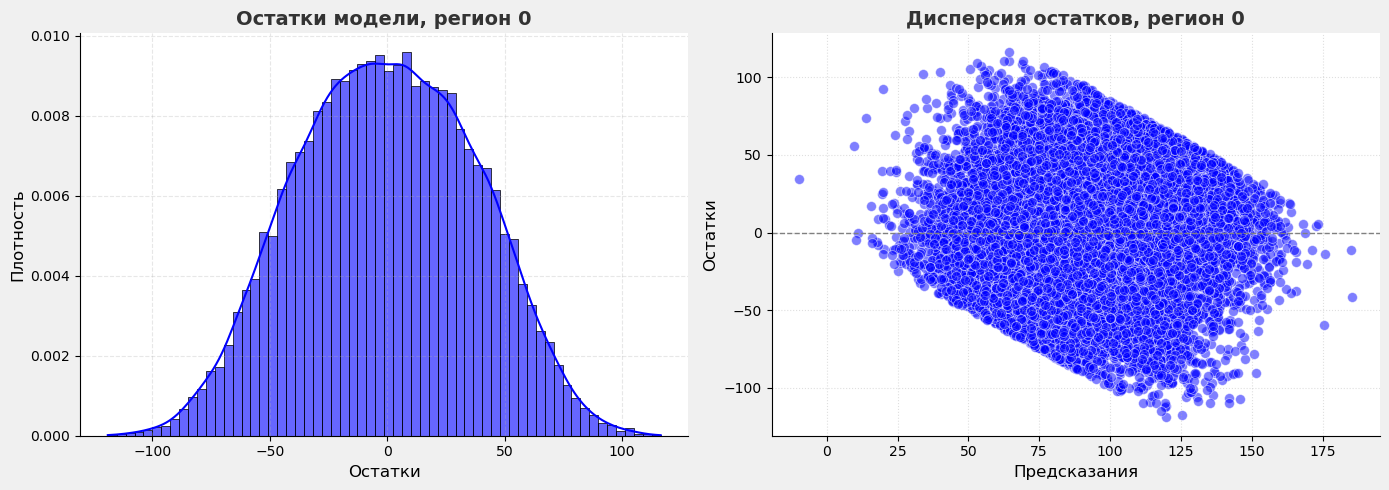

'Регион 1:'

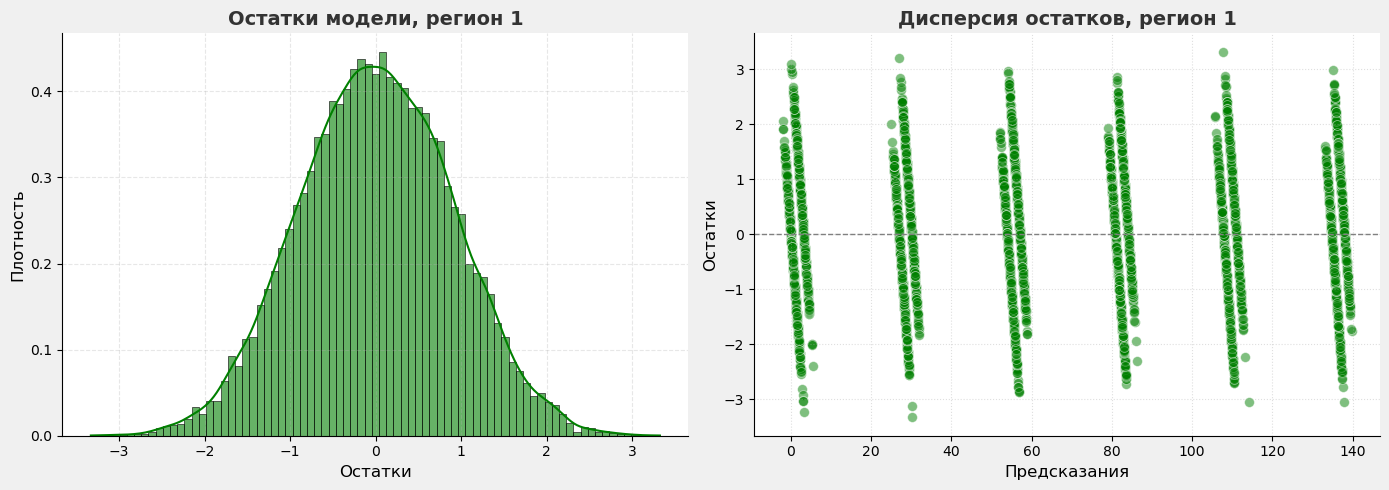

'Регион 2:'

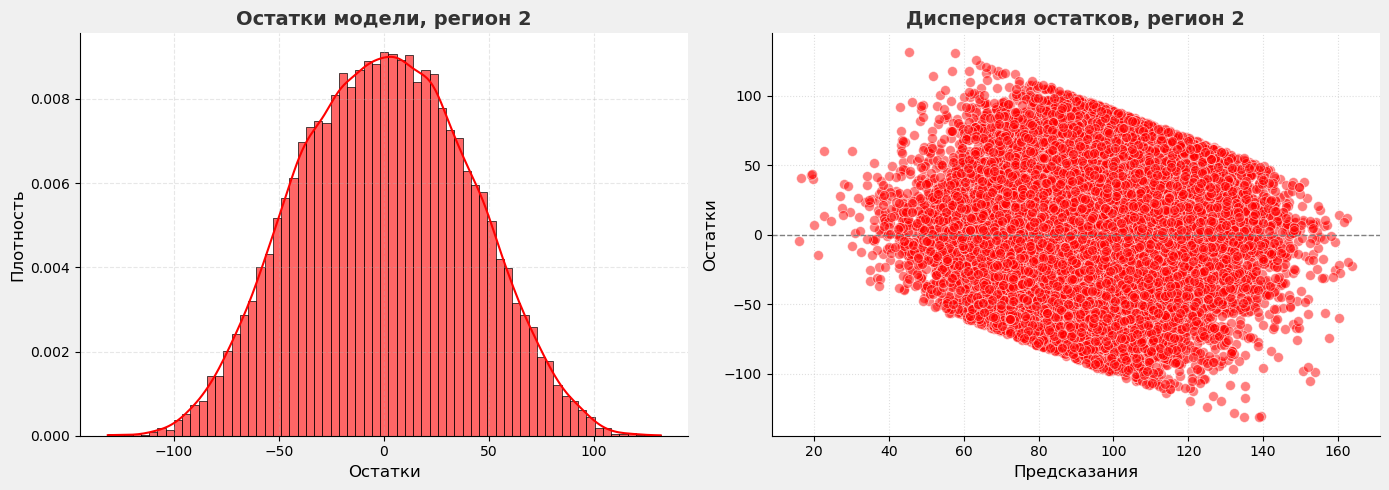

In [18]:
for key, splitted_region in enumerate(splitted_regions):
    residuals = splitted_region['valid']['product'] - splitted_region['valid']['product_pred']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='#f0f0f0') 

    sns.histplot(x=residuals, ax=ax1, kde=True, stat="density", edgecolor='black', color=COLORS[key], alpha=0.6)
    ax1.set_title(f'Остатки модели, регион {key}', fontsize=14, fontweight='bold', color='#333333')
    ax1.set_xlabel('Остатки', fontsize=12)
    ax1.set_ylabel('Плотность', fontsize=12)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.grid(True, linestyle='--', alpha=0.3)

    sns.scatterplot(
        x=splitted_region['valid']['product_pred'], y=residuals, ax=ax2,
        alpha=0.5, color=COLORS[key], edgecolor='w', s=50
    )
    ax2.set_title(f'Дисперсия остатков, регион {key}', fontsize=14, fontweight='bold', color='#333333')
    ax2.set_xlabel('Предсказания', fontsize=12)
    ax2.set_ylabel('Остатки', fontsize=12)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.grid(True, linestyle=':', alpha=0.4)
    ax2.axhline(0, color='gray', linestyle='--', linewidth=1) 
    plt.tight_layout()

    display(f'Регион {key}:')
    plt.show()


По диаграммам остатков для всех трех регионов можно сделать вывод, что модель хорошо подходит и не содержит явных признаков нарушения предположений о нормальности, гомоскедастичности и отсутствии автокорреляции остатков. Это свидетельствует о корректности построенной модели и ее пригодности для оценки запасов в скважинах.

## Подготовка к расчёту прибыли

In [19]:
analized_counts = 500
selected_counts = 200  
money = 10000000000  
profite = 450000 
vero = 0.025

In [20]:
obrab = money / selected_counts / profite
round(obrab)

111

Достаточный объём сырья для безубыточной разработки новой скважины составляет около 111 тыс. баррелей, что превышает средний запас предсказанного сырья в каждом из регионов.Напишем функцию для расчёта прибыли по выбранным скважинам.

In [21]:
def calc_profit(analized_counts_df, selected_counts, product_unit_price, money):
    sort_well = analized_counts_df.sort_values(by='product_pred', ascending=False)
    selected_wells = sort_well.iloc[:selected_counts]
    profit = product_unit_price * selected_wells['product'].sum() - money
    return profit


## Расчёт прибыли и рисков

In [22]:
BOOTSTRAP_COUNT = 1000

results = pd.DataFrame(columns=['Средняя прибыль', '95%-й доверительный интервал', 
                                'Вероятность убытков, %', 'Регион подходит'])
for key, splitted_region in enumerate(splitted_regions):
    state = np.random.RandomState(RANDOM_STATE)
    
    profits = []
    for i in range(BOOTSTRAP_COUNT):
        analyzed_wells = splitted_region['valid'].sample(n=analized_counts, replace=True, random_state=state)
        profit = calc_profit(analyzed_wells, selected_counts, profite, money)
        profits.append(profit)
    profits = pd.Series(profits)

    profit_mean = profits.mean()
    profit_lower = profits.quantile(0.025)
    profit_upper = profits.quantile(0.975)
    less_prob = (profits < 0).mean()
    results.loc[f'Регион {key}'] = [int(profit_mean), 
                                    f'{int(profit_lower)} — {int(profit_upper)}',
                                    less_prob * 100,
                                    'да' if less_prob < vero else 'нет']
results

,Средняя прибыль,95%-й доверительный интервал,"Вероятность убытков, %",Регион подходит
Регион 0,403572063,-137690003 — 902848310,5.9,нет
Регион 1,430208352,43052519 — 847313467,1.6,да
Регион 2,384214428,-127589876 — 910134439,8.0,нет


После проведения оценки рисков будут отобраны только те регионы, где вероятность возникновения убытков не превышает 2,5%. Таким образом, для разработки скважин рекомендуется регион 1, в котором риск убытков оценивается всего в 1,6%.

## Общий вывод

В рамках работы были собраны, обработаны и проанализированы данные по пробам нефти из трёх регионов. Для каждого региона построены модели, позволяющие прогнозировать объём запасов сырья в скважинах. Оценка вероятной прибыли и рисков проведена с использованием метода Bootstrap.

В процессе предварительной обработки обнаружено небольшое число пропущенных значений, не оказавших существенного влияния на дальнейший анализ.

Результаты исследовательского анализа данных показали, что входные признаки являются количественными и непрерывными переменными, часть из которых имеют ненормальное распределение. Мультиколлинеарность между признаками, способная ухудшить качество моделей, не выявлена. Для региона 1 отмечена высокая корреляция признака f2 с целевым признаком product.

Обучение и тестирование моделей подтвердили, что модель региона 1 демонстрирует наилучшие результаты по метрике RMSE — корень среднеквадратичной ошибки существенно ниже, чем у моделей других регионов. При этом для региона 1 предсказан минимальный средний объём запасов нефти в скважинах.

Подсчёт рисков и прибыли на основе Bootstrap позволил определить, что регион 1 является наиболее перспективным для разработки, с прогнозами по следующим показателям:

Средняя прибыль составляет около 430 миллионов единиц;

95%-й доверительный интервал варьируется от 43 до 847 миллионов;

Вероятность убытков в регионе не превышает 1.6%.

Таким образом, регион 1 обладает оптимальным сочетанием прогноза запасов, качества моделей и финансовых показателей для эффективного освоения месторождения.